In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.colors import TangoColors
from analysis.utils.event_display import show_hist_plots, show_scatter_plots
from analysis.utils.geometry import Geometry, get_geometry, get_rebinned_geometry
from analysis.utils.plot_utils import add_legend, setup
from analysis.utils.preprocessing_utils import create_parquet_from_root, get_rebinned_df
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
)

In [3]:
setup()

In [7]:
run = 10001
chunk = 13
geometry_label = "200um_bins"
root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
parquet_hits_path = (
    get_parquet_path() / f"{run:05d}/{geometry_label}/{run:05d}_{chunk:03d}_hits.parq"
)
parquet_truth_path = (
    get_parquet_path() / f"{run:05d}/{geometry_label}/{run:05d}_{chunk:03d}_truth.parq"
)
geometry_path = get_parquet_path() / f"{run:05d}/geometry.pkl"

In [8]:
hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)
geo = get_geometry(geo_path=geometry_path)
geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

In [19]:
latex_labels = [
    "Other particle",
    r"Other $e^{\pm}$",
    r"Primary $e^{\pm}$",
    r"$\mu^{\pm}$",
]
sizes = [1, 1, 1, 5]
colors = [
    TangoColors.sky_blue,
    TangoColors.orange,
    TangoColors.scarlet_red,
    TangoColors.chameleon,
]

## Event Displays


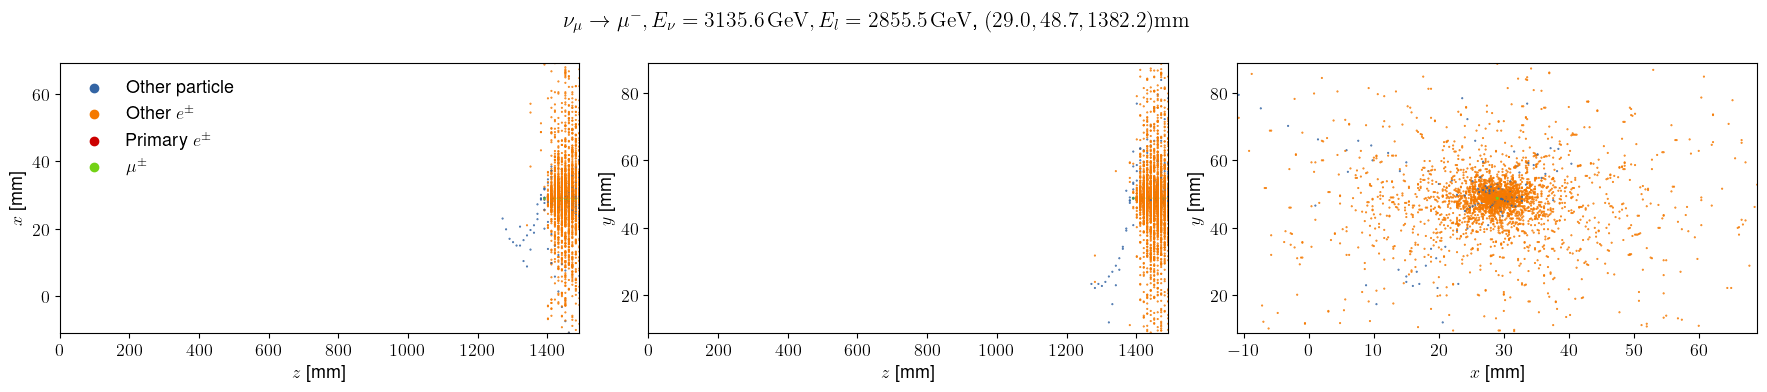

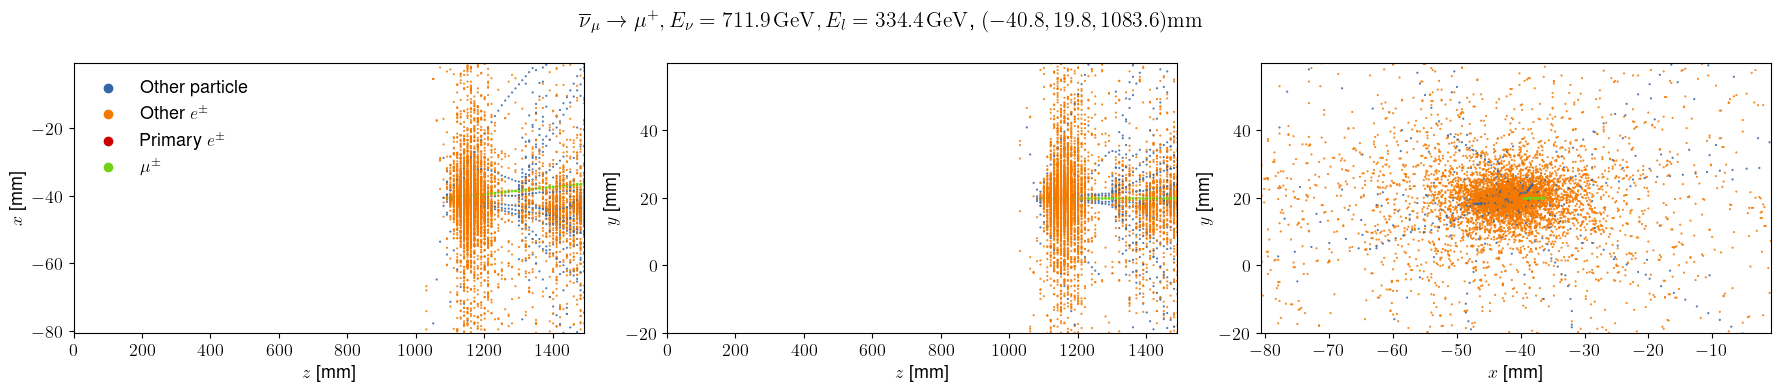

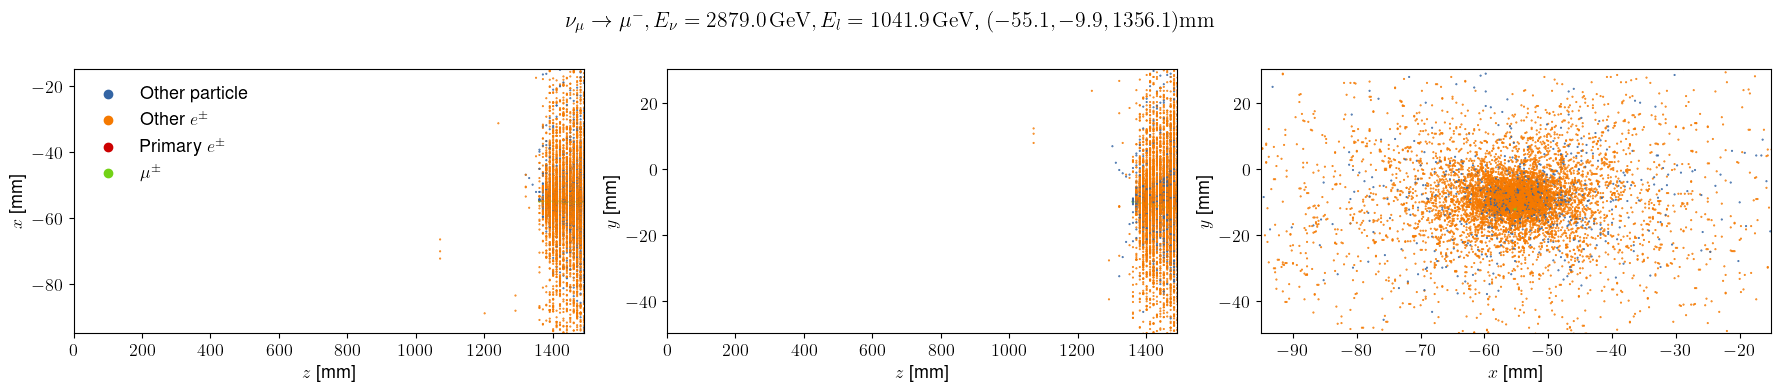

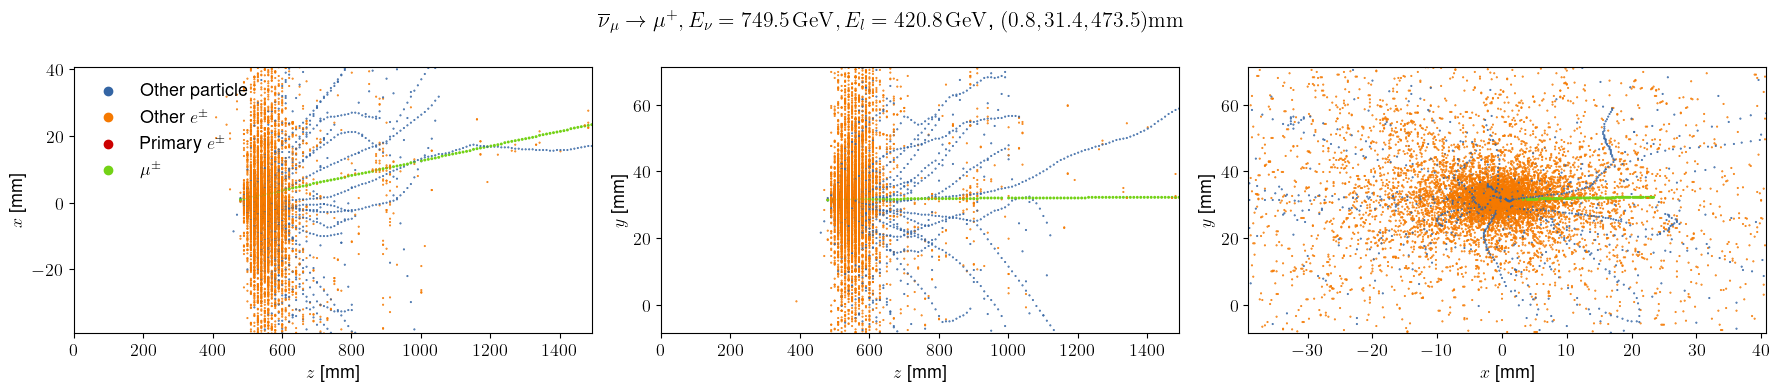

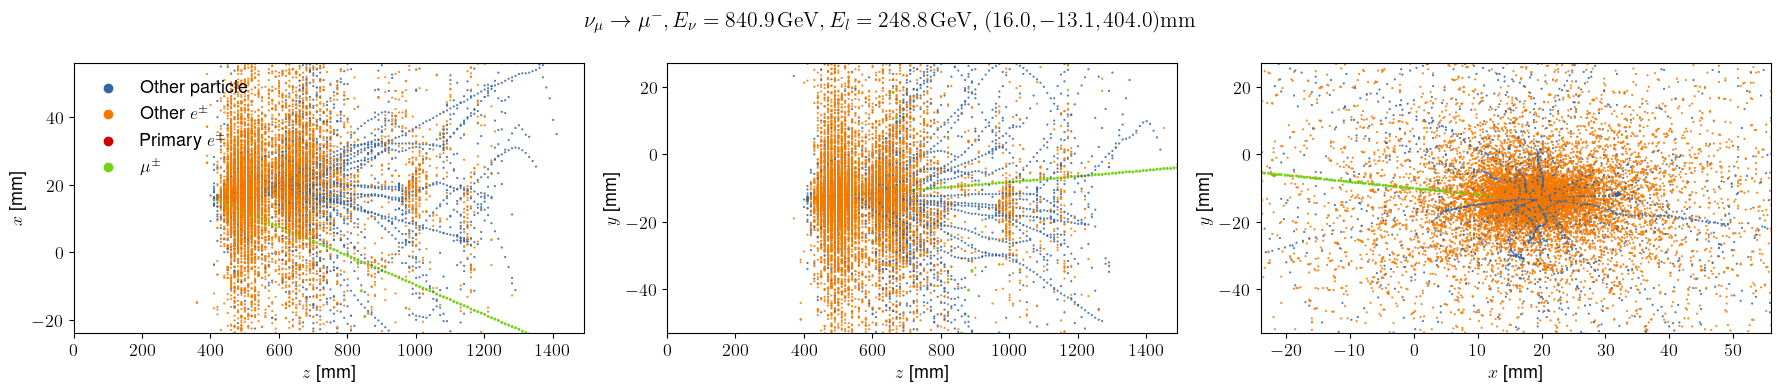

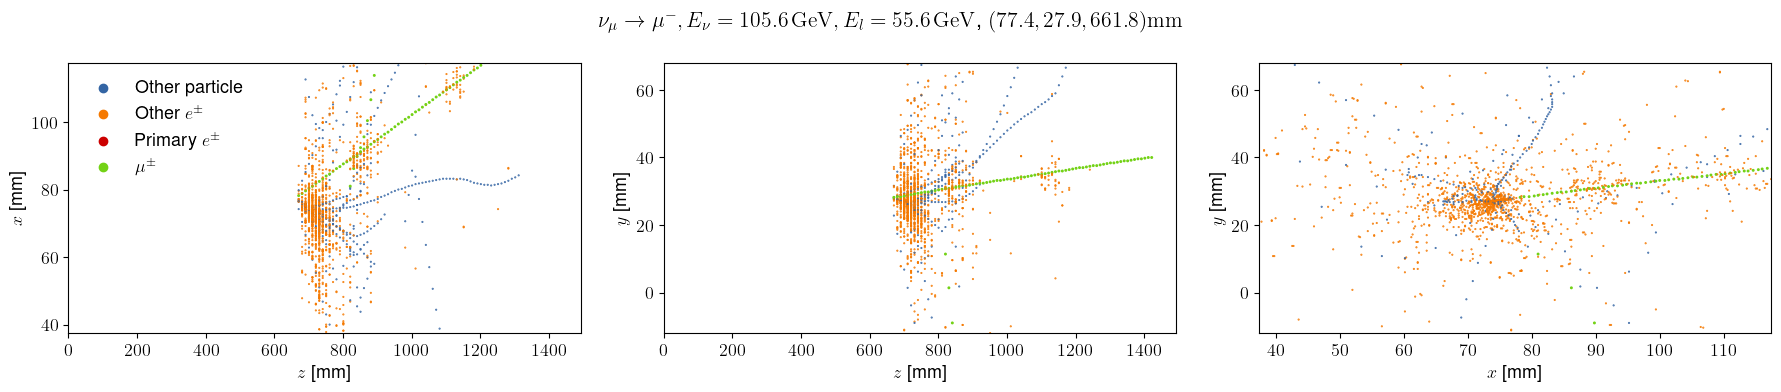

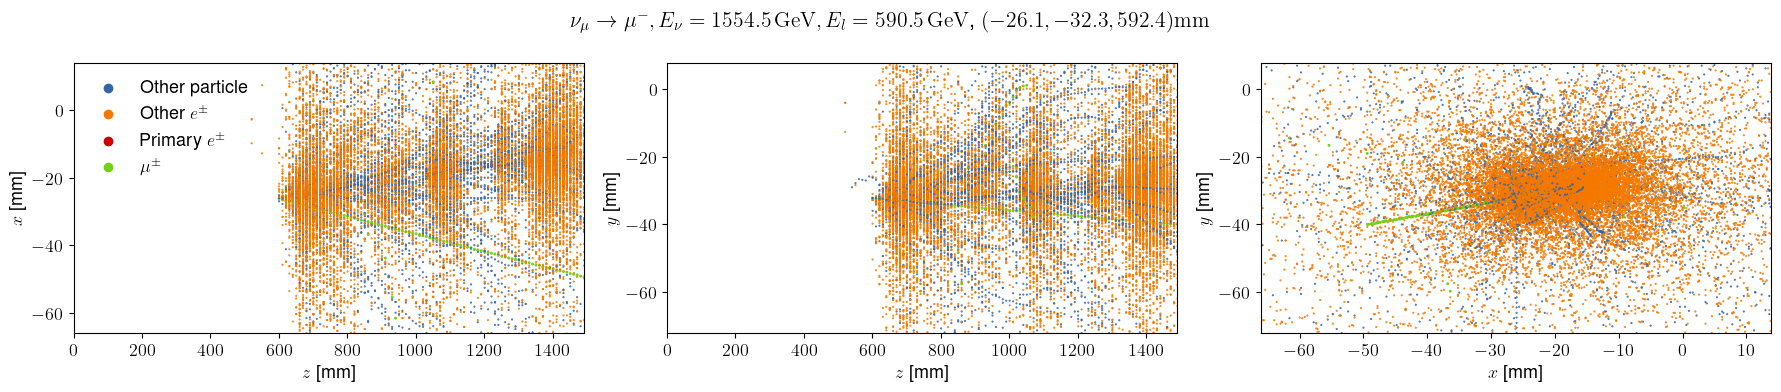

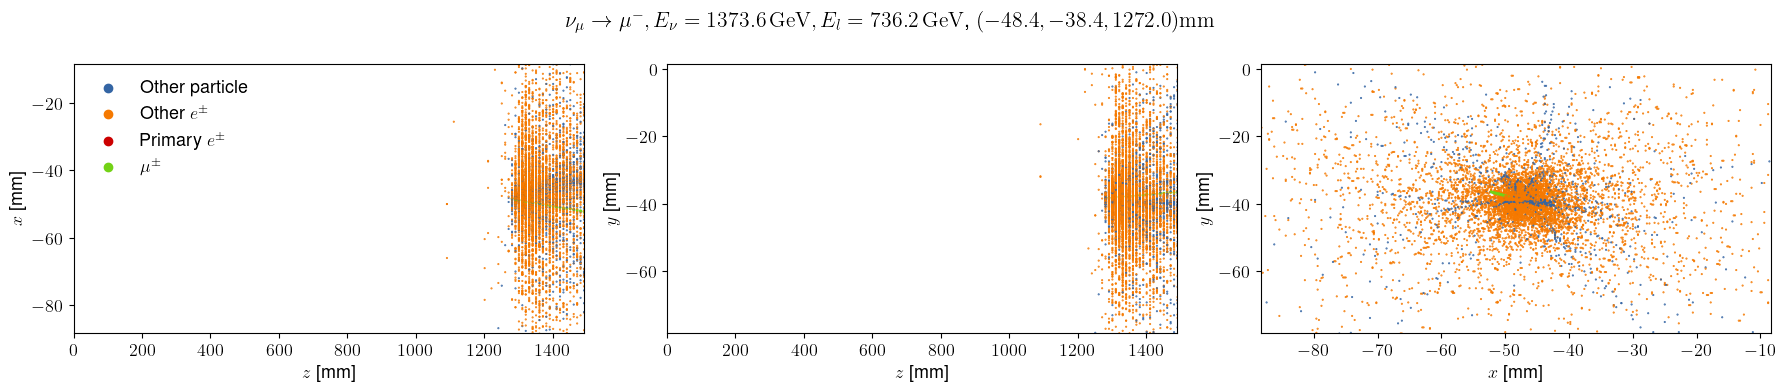

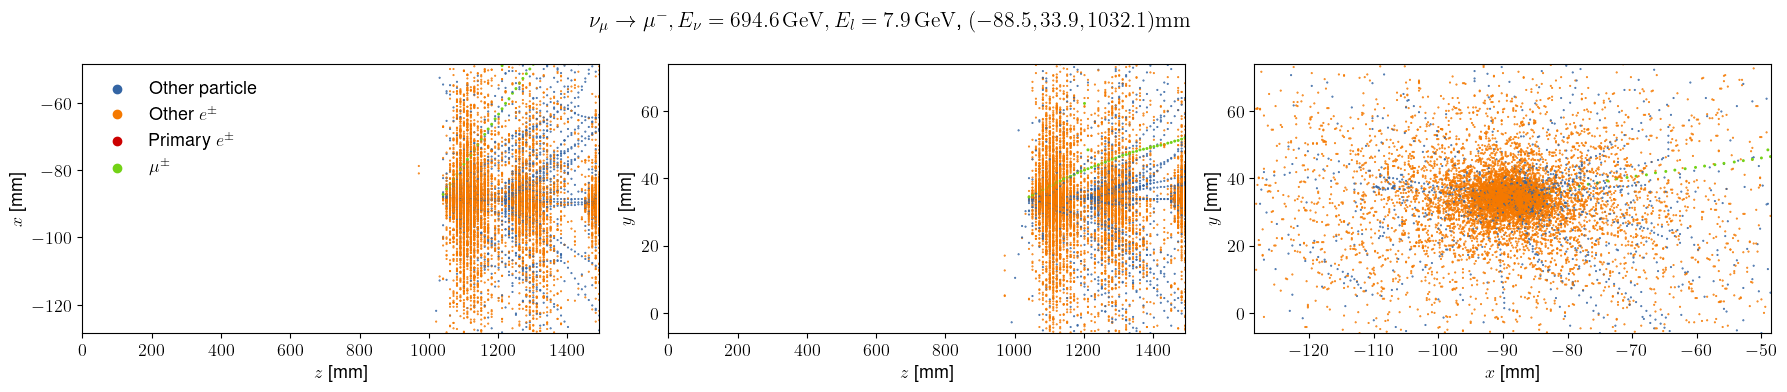

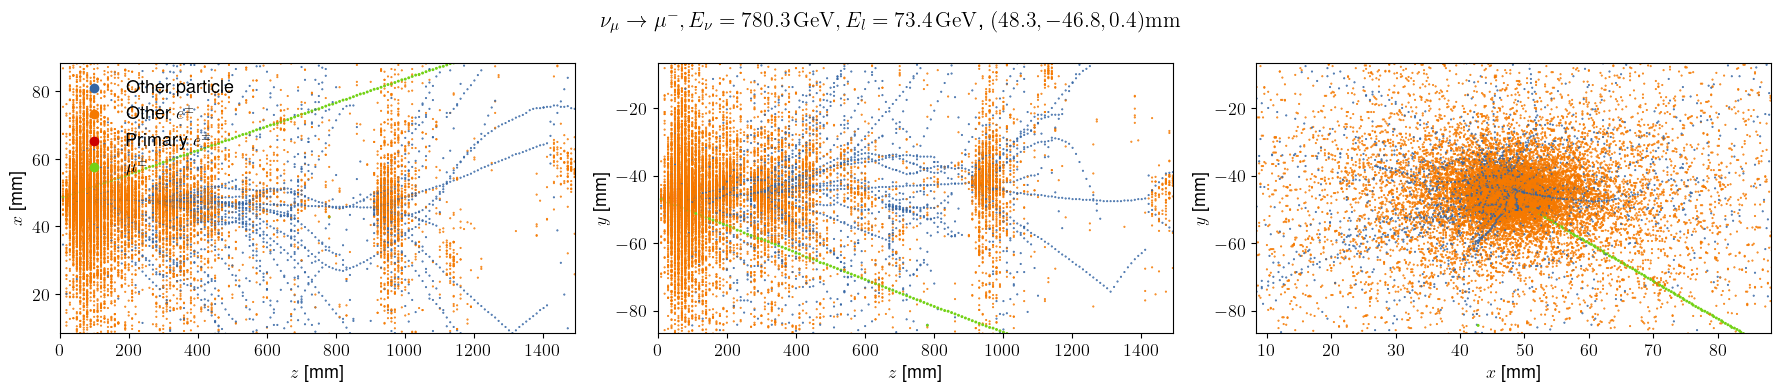

In [20]:
for event_id in range(10):
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}").copy()
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    event_hits["color"] = TangoColors.sky_blue
    event_hits["size"] = 1
    for i, (color, size) in enumerate(zip(colors, sizes)):
        event_hits.loc[event_hits["pdg_label"] == i, "color"] = color
        event_hits.loc[event_hits["pdg_label"] == i, "size"] = size

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["color"].values,
        s=event_hits["size"].values,
    )
    for label, color in zip(latex_labels, colors):
        axs[0].scatter([], [], c=color, label=label)

    axs[0].legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)

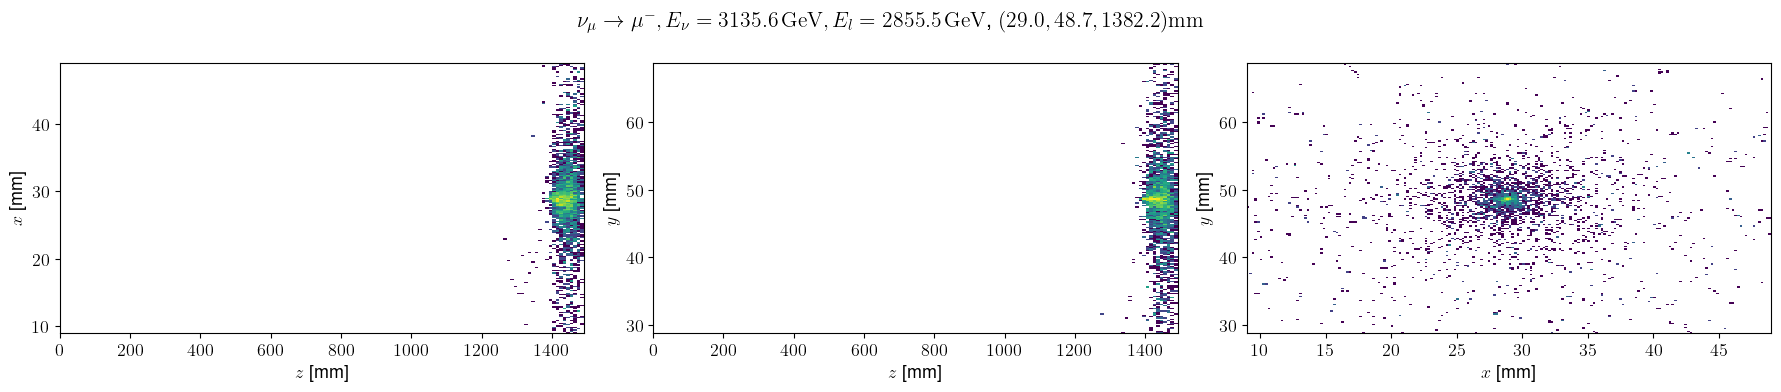

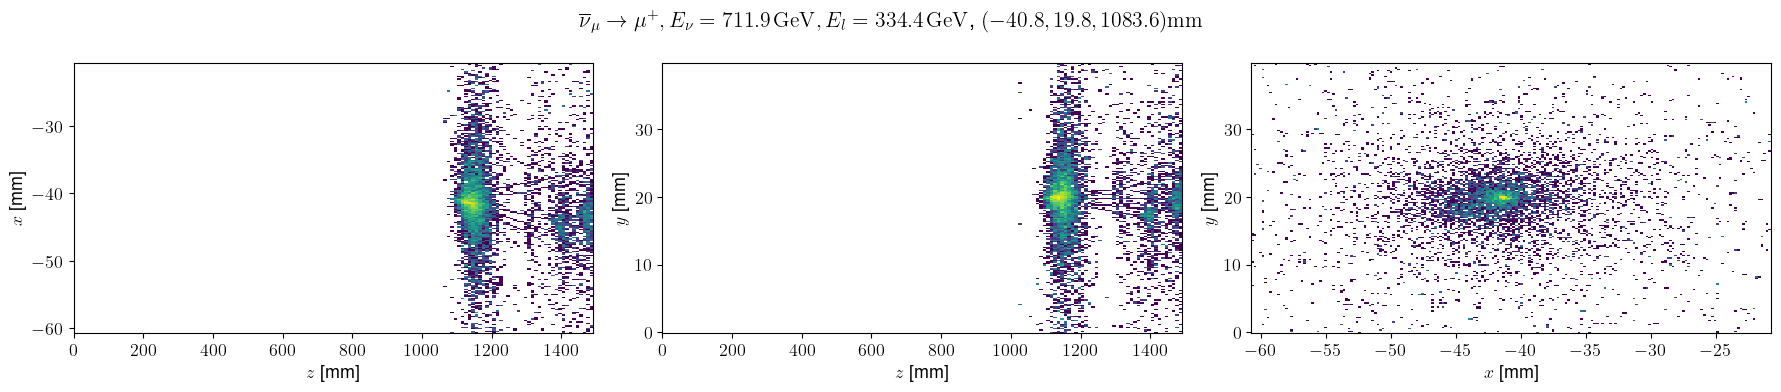

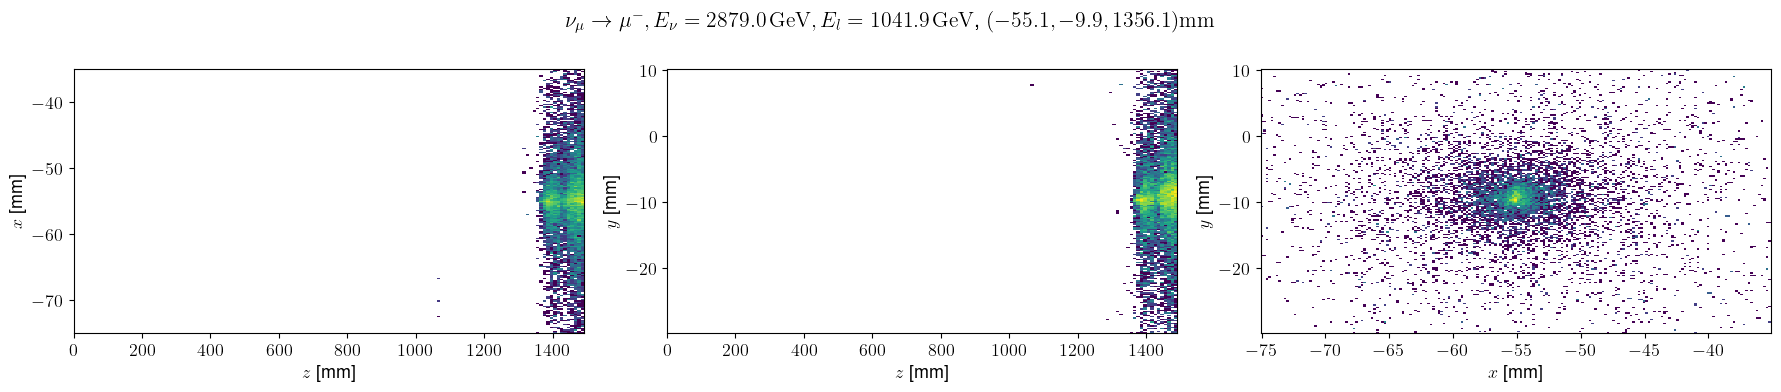

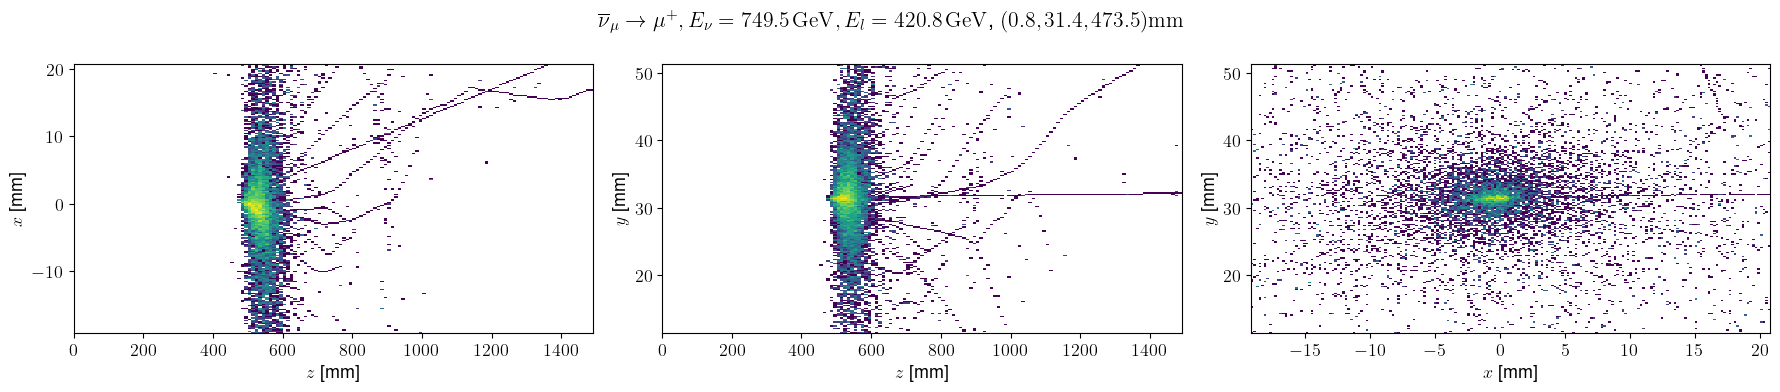

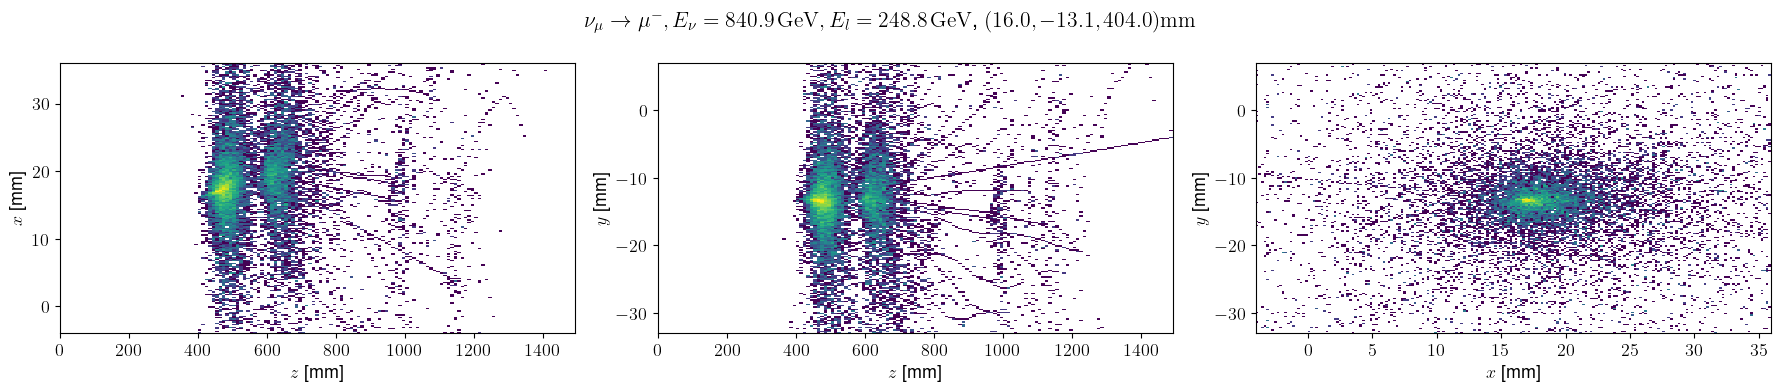

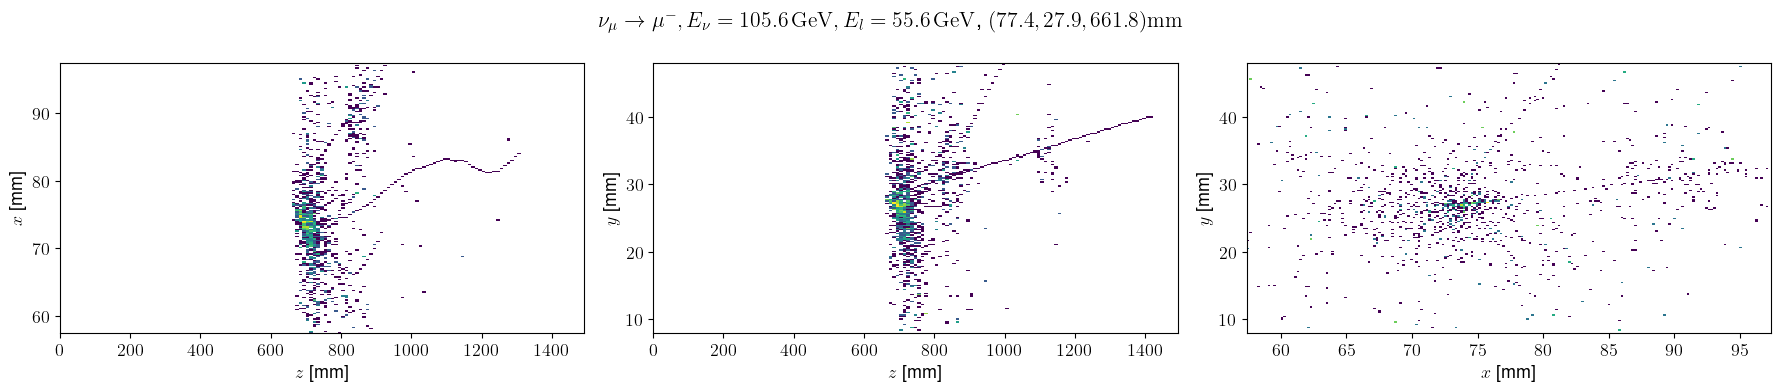

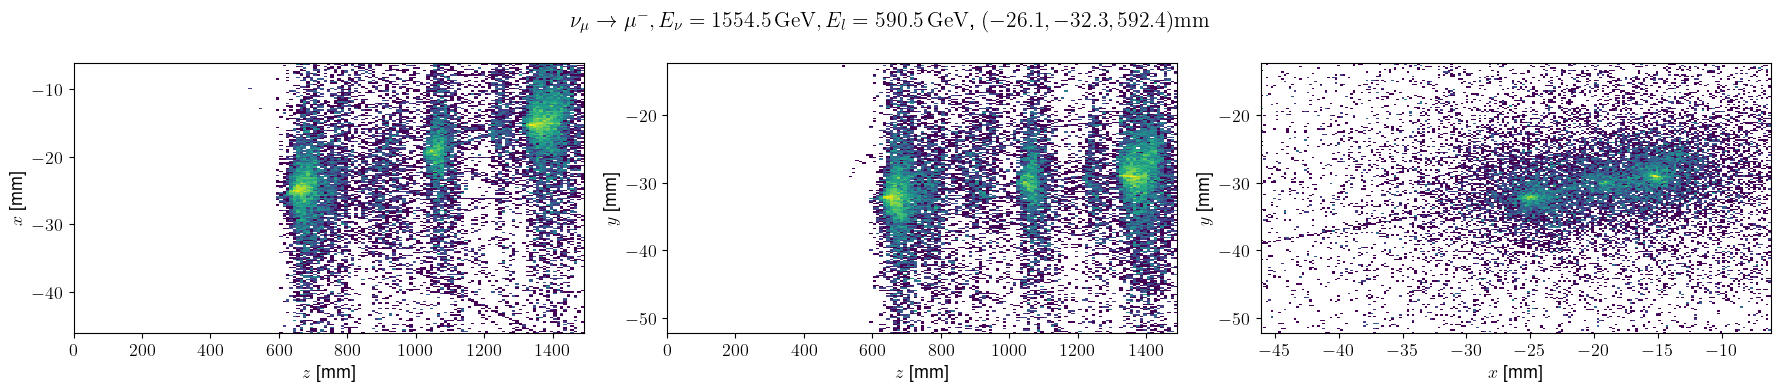

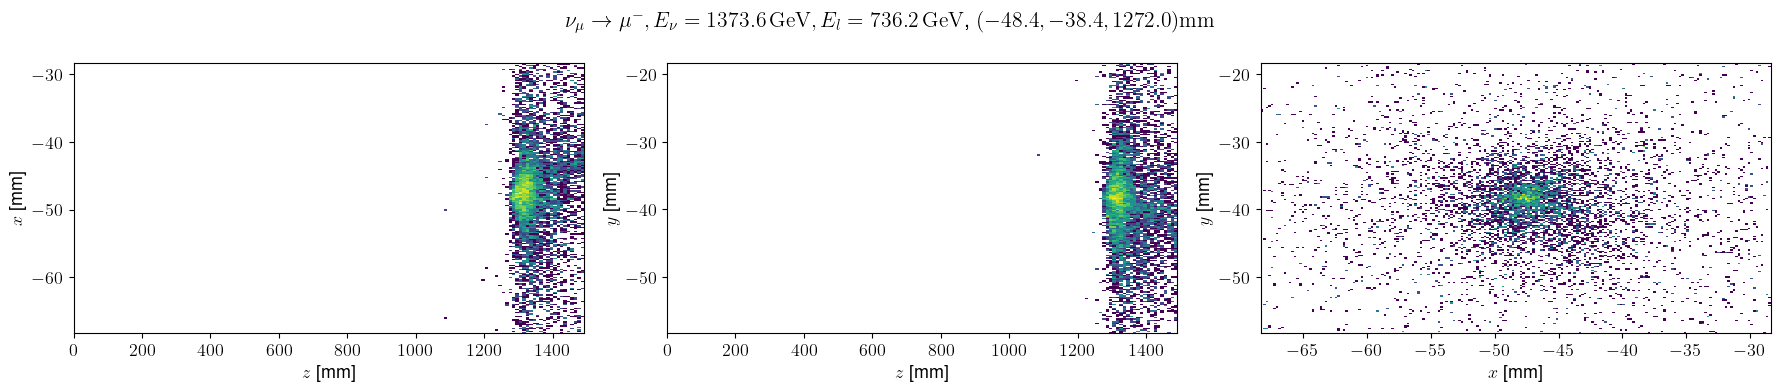

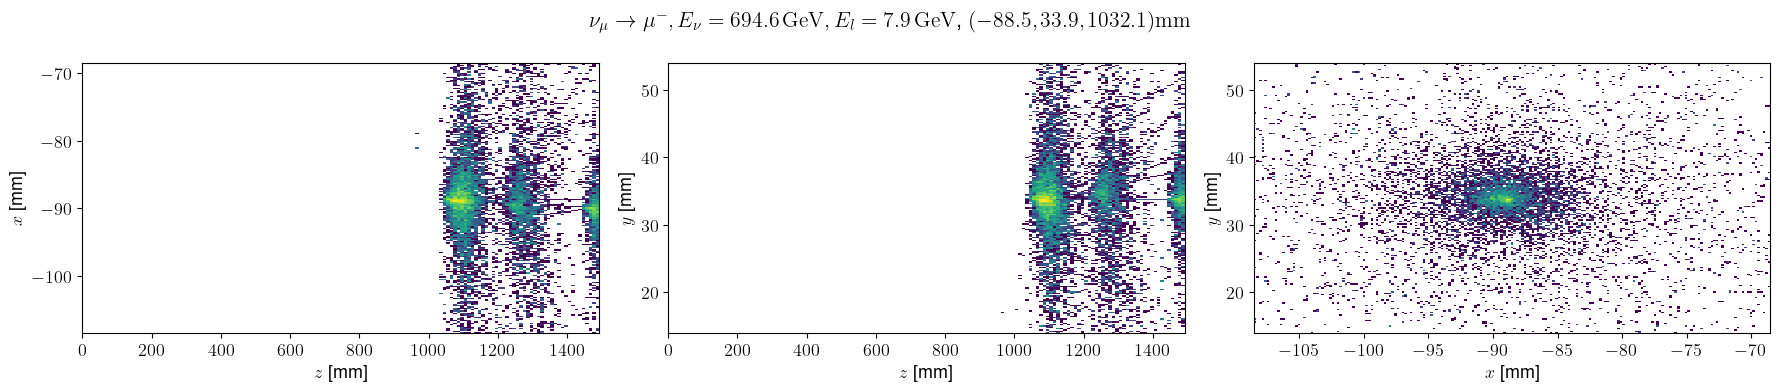

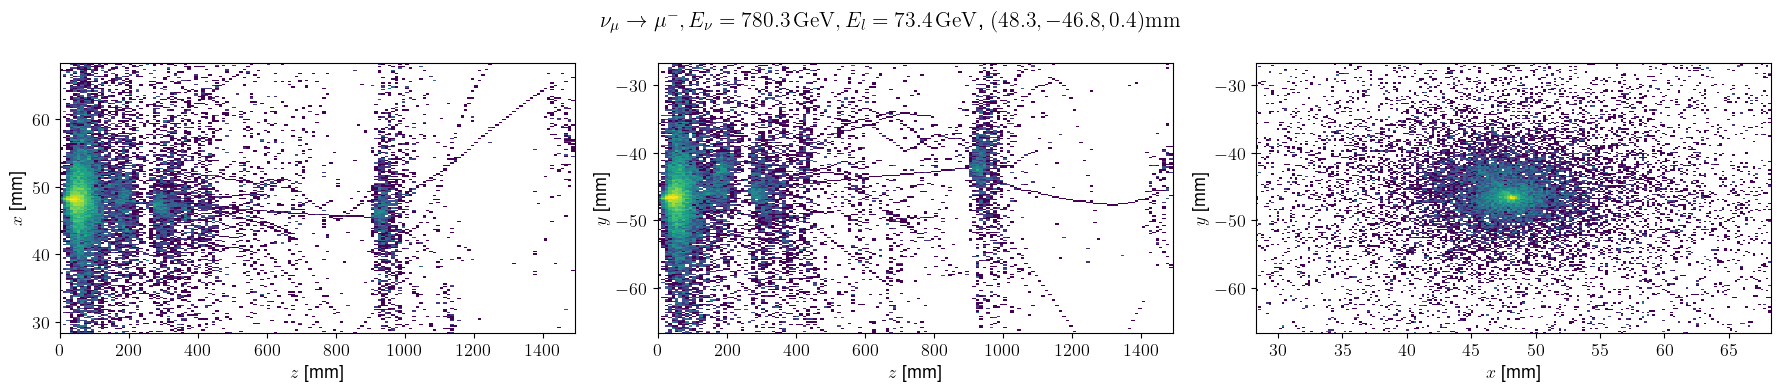

In [12]:
for event_id in range(10):
    event_hits = hits_df.query(f"event_id == {event_id}")
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))
    # show_scatter_plots(df=event_hits, truth=truth, geo=geo, range=20)
    # show_hist_plots(df=event_hits, truth=truth, geo=geo, range=20)
    show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=20)